In [1]:
# Importando bibliotecas essenciais
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Carregando os nomes das colunas do arquivo de features
data_path = '../../data/processed'
try:
    df_features = pd.read_csv(os.path.join(data_path, 'UNSW-NB15_features.csv'), encoding='latin-1')
    col_names = df_features['Name'].tolist()
except FileNotFoundError:
    print("Arquivo 'UNSW-NB15_features.csv' não encontrado. Definindo nomes das colunas manualmente.")
    # Nomes retirados dos artigos e da estrutura do dataset
    col_names = ['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label']


# Carregando os datasets de treino e teste
# O 'id' não é uma feature, então o ignoramos, mas vamos mantê-lo por enquanto para inspeção
train_path = os.path.join(data_path, 'ubuntu_server_dataset_train.csv')
test_path = os.path.join(data_path, 'ubuntu_server_dataset_test.csv')

# Os CSVs originais não têm cabeçalho, então definimos os nomes manualmente.
# O arquivo de treino parece ter uma coluna extra 'id' no início.
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)


print("Formato do dataset de treino:", df_train.shape)
print("Formato do dataset de teste:", df_test.shape)

Arquivo 'UNSW-NB15_features.csv' não encontrado. Definindo nomes das colunas manualmente.
Formato do dataset de treino: (7961, 45)
Formato do dataset de teste: (3415, 45)


In [3]:
print("--- Primeiras 5 linhas do Dataset de Treino ---")
display(df_train.head())

print("\n--- Informações do Dataset de Treino ---")
df_train.info()

print("\n\n--- Primeiras 5 linhas do Dataset de Teste ---")
display(df_test.head())

print("\n--- Informações do Dataset de Teste ---")
df_test.info()

--- Primeiras 5 linhas do Dataset de Treino ---


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0,0.299855,tcp,-,SH,8.0,0.0,378.0,0.0,26.679562,0,0,10084.874356,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47,0,0.0,0.0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,0,8499.657490,unknown_transport,-,OTH,709.0,0.0,0.0,0.0,0.083415,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2,0,1,1,1,1,0,0,0,2,1,0,Normal,0
2,0,8499.656950,unknown_transport,-,OTH,700.0,0.0,0.0,0.0,0.082356,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,3,0,1,2,1,1,0,0,0,3,1,0,Normal,0
3,0,8501.655729,unknown_transport,-,OTH,700.0,0.0,0.0,0.0,0.082337,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,4,0,1,3,1,1,0,0,0,4,1,0,Normal,0
4,0,8525.656374,unknown_transport,-,OTH,712.0,0.0,0.0,0.0,0.083513,0,0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,5,0,1,4,1,1,0,0,0,5,1,0,Normal,0



--- Informações do Dataset de Treino ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7961 entries, 0 to 7960
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7961 non-null   int64  
 1   dur                7961 non-null   float64
 2   proto              7961 non-null   object 
 3   service            7961 non-null   object 
 4   state              7961 non-null   object 
 5   spkts              7961 non-null   float64
 6   dpkts              7961 non-null   float64
 7   sbytes             7961 non-null   float64
 8   dbytes             7961 non-null   float64
 9   rate               7961 non-null   float64
 10  sttl               7961 non-null   int64  
 11  dttl               7961 non-null   int64  
 12  sload              7961 non-null   float64
 13  dload              7961 non-null   float64
 14  sloss              7961 non-null   float64
 15  dloss              7961 non-nu

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0,0.720728,tcp,http,SH,17.0,0.0,1613.0,0.0,23.587262,0,0,17904.119168,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,94,0,1.0,0.0,38,0,92,38,1,92,0,16,38,92,38,0,Normal,0
1,0,1.274111,tcp,-,SH,26.0,1.0,3485.0,0.0,21.191246,0,0,21881.923945,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,134,0,0.0,0.0,39,0,92,7,1,92,0,16,37,92,39,0,Normal,0
2,0,2.231106,tcp,ftp,SH,19.0,1.0,99.0,0.0,8.964164,0,0,354.980893,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.000000,0.000000,0.000000,5,0,0.0,0.0,16,0,92,16,1,92,1,16,37,92,16,0,Normal,0
3,0,0.527472,tcp,-,FIN,39.0,27.0,51926.0,1470.0,125.125125,128,64,787545.120878,22295.022295,0.0,0.0,0.0,0.0,0.0,0.0,65280.0,2.072169e+09,2.497862e+09,86144.0,0.000723,0.000021,0.000702,1331,54,0.0,0.0,39,0,92,1,1,92,0,16,37,92,39,0,Normal,0
4,0,0.862385,tcp,-,FIN,21.0,9.0,1266.0,50288.0,34.787247,128,64,11744.174586,466501.620506,0.0,0.0,0.0,0.0,0.0,0.0,65280.0,3.105837e+09,2.765092e+09,64256.0,0.000739,0.000022,0.000717,60,5587,0.0,0.0,39,0,92,1,1,92,0,16,37,92,39,0,Normal,0



--- Informações do Dataset de Teste ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3415 non-null   int64  
 1   dur                3415 non-null   float64
 2   proto              3415 non-null   object 
 3   service            3415 non-null   object 
 4   state              3415 non-null   object 
 5   spkts              3415 non-null   float64
 6   dpkts              3415 non-null   float64
 7   sbytes             3415 non-null   float64
 8   dbytes             3415 non-null   float64
 9   rate               3415 non-null   float64
 10  sttl               3415 non-null   int64  
 11  dttl               3415 non-null   int64  
 12  sload              3415 non-null   float64
 13  dload              3415 non-null   float64
 14  sloss              3415 non-null   float64
 15  dloss              3415 non-nul

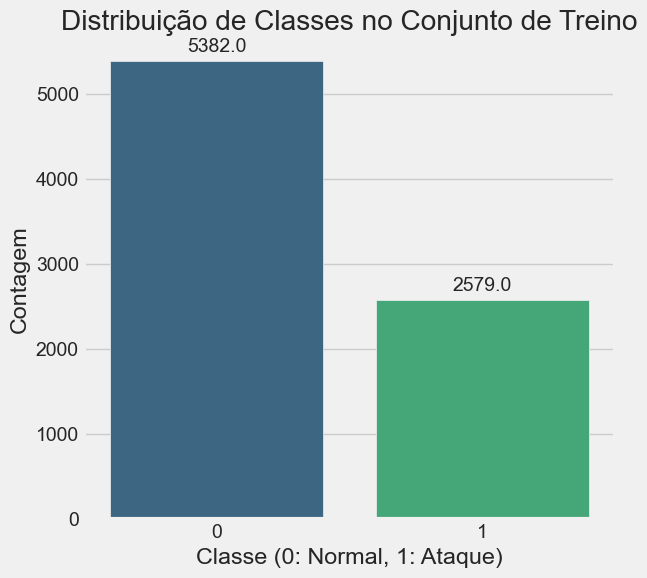

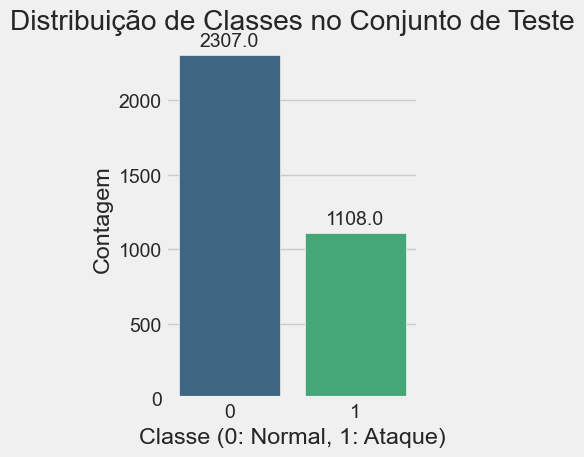

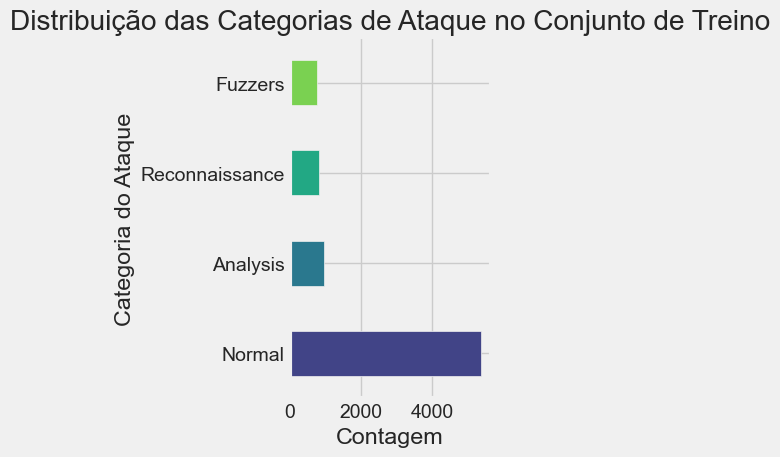

--- Análise das Features Categóricas ---


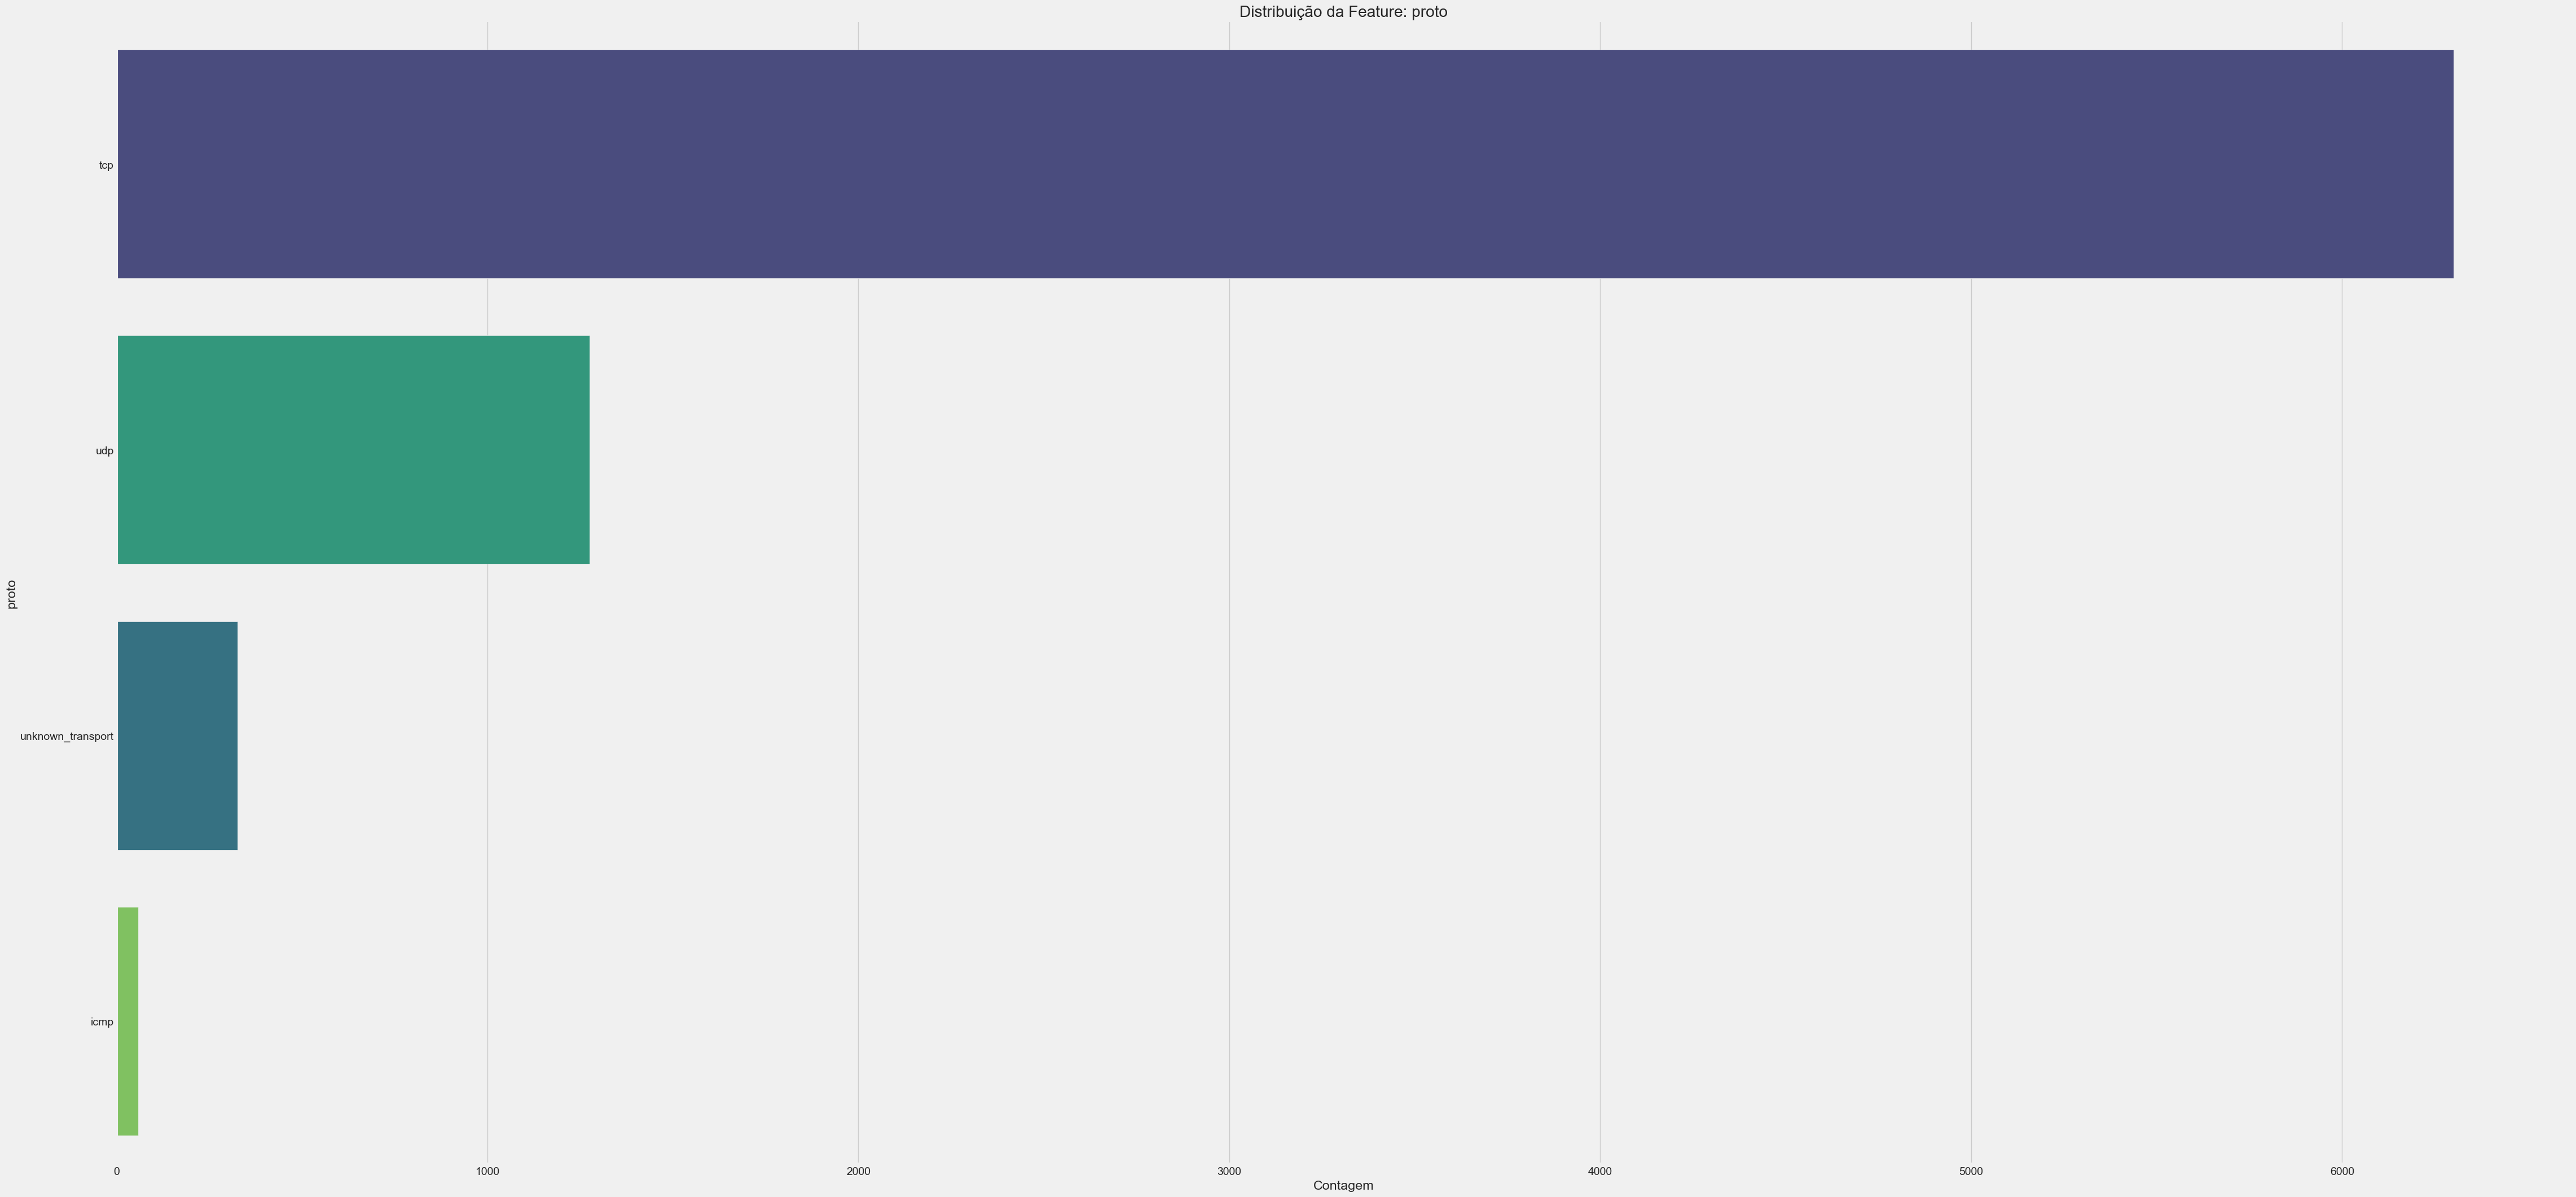

Valores únicos em 'proto': 4
------------------------------


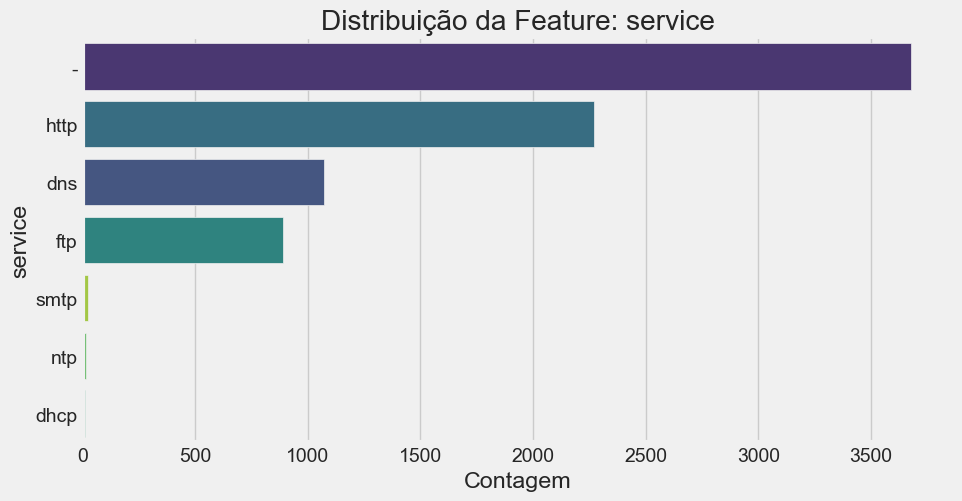

Valores únicos em 'service': 7
------------------------------


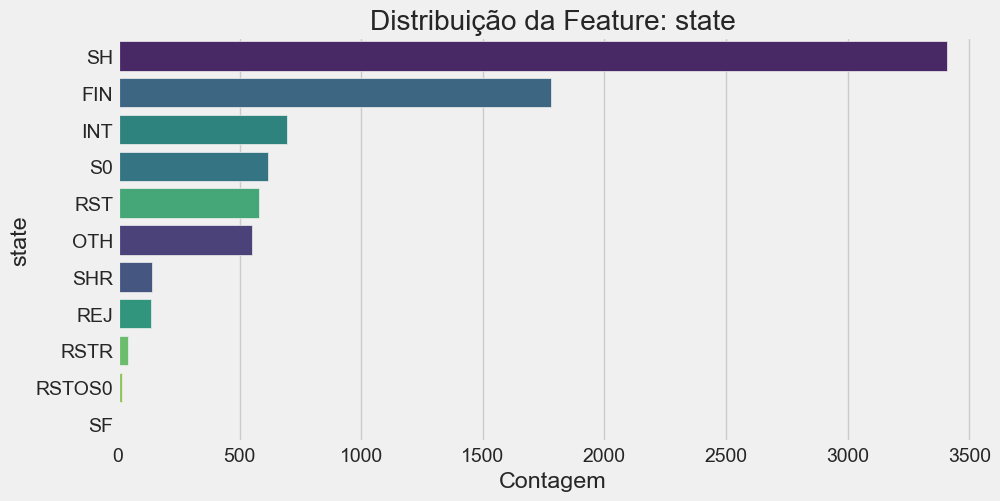

Valores únicos em 'state': 11
------------------------------
Proporção de classes no treino:
label
0    67.604572
1    32.395428
Name: proportion, dtype: float64


In [4]:
# Verificando a distribuição da variável alvo binária (label)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
ax = sns.countplot(x='label', data=df_train, palette='viridis', hue='label', legend=False)
plt.title('Distribuição de Classes no Conjunto de Treino')
plt.xlabel('Classe (0: Normal, 1: Ataque)')
plt.ylabel('Contagem')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

plt.subplot(1, 2, 1)
ax = sns.countplot(x='label', data=df_test, palette='viridis', hue='label', legend=False)
plt.title('Distribuição de Classes no Conjunto de Teste')
plt.xlabel('Classe (0: Normal, 1: Ataque)')
plt.ylabel('Contagem')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.tight_layout()
plt.show()

# Verificando a distribuição das categorias de ataque (attack_cat)
plt.subplot(1, 2, 2)
plt.title('Distribuição das Categorias de Ataque no Conjunto de Treino')
df_train['attack_cat'].value_counts().plot(kind='barh', color=sns.color_palette("viridis", len(df_train['attack_cat'].unique())))
plt.xlabel('Contagem')
plt.ylabel('Categoria do Ataque')

plt.tight_layout()
plt.show()

# Identificando as colunas categóricas
categorical_cols = ['proto', 'service', 'state']

print("--- Análise das Features Categóricas ---")
for col in categorical_cols:
    if col == 'proto':
        plt.figure(figsize=(50, 25))
        sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribuição da Feature: {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
        plt.show()
        print(f"Valores únicos em '{col}': {df_train[col].nunique()}")
        print("-" * 30)
    else:
        plt.figure(figsize=(10, 5))
        sns.countplot(y=col, data=df_train, order=df_train[col].value_counts().index, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribuição da Feature: {col}')
        plt.xlabel('Contagem')
        plt.ylabel(col)
        plt.show()
        print(f"Valores únicos em '{col}': {df_train[col].nunique()}")
        print("-" * 30)

# Proporções
print("Proporção de classes no treino:")
print(df_train['label'].value_counts(normalize=True) * 100)

--- Estatísticas Descritivas (Features Numéricas) ---


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,7961.0,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7.961000e+03,7961.000000,7961.000000,7.961000e+03,7.961000e+03,7961.0,7961.0,7961.0,7961.0,7961.0,7961.0,7.961000e+03,7.961000e+03,7.961000e+03,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.0,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.000000,7961.0,7961.000000
mean,0.0,28.570592,18.893104,4.570406,7515.139932,6583.795377,1.118413e+04,33.659339,18.980530,3.879036e+06,1.977638e+06,0.0,0.0,0.0,0.0,0.0,0.0,1.058441e+06,6.353794e+08,4.794974e+08,18063.177993,0.000167,0.000007,0.000160,206.794121,676.425072,0.870242,0.0,29.728175,9.871875,66.038437,14.193066,2.345936,59.023364,0.111669,11.039191,28.130888,62.367416,30.649542,0.0,0.323954
std,0.0,641.854919,54.989147,10.335422,20708.307613,20408.959207,5.705273e+04,53.889154,29.233555,6.469884e+07,8.563655e+06,0.0,0.0,0.0,0.0,0.0,0.0,4.004840e+06,1.188210e+09,1.066868e+09,35285.525470,0.000377,0.000021,0.000366,396.159436,1967.581384,4.294512,0.0,21.606200,29.398555,31.388717,15.057904,8.772296,32.731901,0.314979,5.190489,9.913075,30.701076,22.059109,0.0,0.468012
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.000000
25%,0.0,0.179242,2.000000,0.000000,99.000000,0.000000,9.833712e+00,0.000000,0.000000,4.062341e+02,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.0,16.000000,0.000000,63.000000,1.000000,1.000000,30.000000,0.000000,9.000000,24.000000,33.000000,16.000000,0.0,0.000000
50%,0.0,0.701679,17.000000,0.000000,848.000000,0.000000,2.316161e+01,0.000000,0.000000,1.477498e+04,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000,0.000000,0.0,27.000000,0.000000,76.000000,8.000000,1.000000,68.000000,0.000000,12.000000,29.000000,69.000000,30.000000,0.0,0.000000
75%,0.0,1.082349,19.000000,1.000000,1613.000000,54.000000,4.964257e+01,64.000000,64.000000,2.123670e+04,2.579717e+04,0.0,0.0,0.0,0.0,0.0,0.0,6.528000e+04,6.634313e+08,0.000000e+00,0.000000,0.000000,0.000000,0.000000,94.000000,54.000000,1.000000,0.0,36.000000,0.000000,90.000000,25.000000,1.000000,89.000000,0.000000,15.000000,34.000000,91.000000,38.000000,0.0,1.000000
max,0.0,21558.937378,1915.000000,66.000000,111137.000000,108593.000000,2.000000e+06,255.000000,64.000000,3.288000e+09,2.160000e+08,0.0,0.0,0.0,0.0,0.0,0.0,1.644544e+07,4.289083e+09,4.288574e+09,167936.000000,0.003410,0.000869,0.003382,2191.000000,9909.000000,59.000000,0.0,100.000000,100.000000,100.000000,73.000000,100.000000,100.000000,1.000000,19.000000,65.000000,100.000000,100.000000,0.0,1.000000


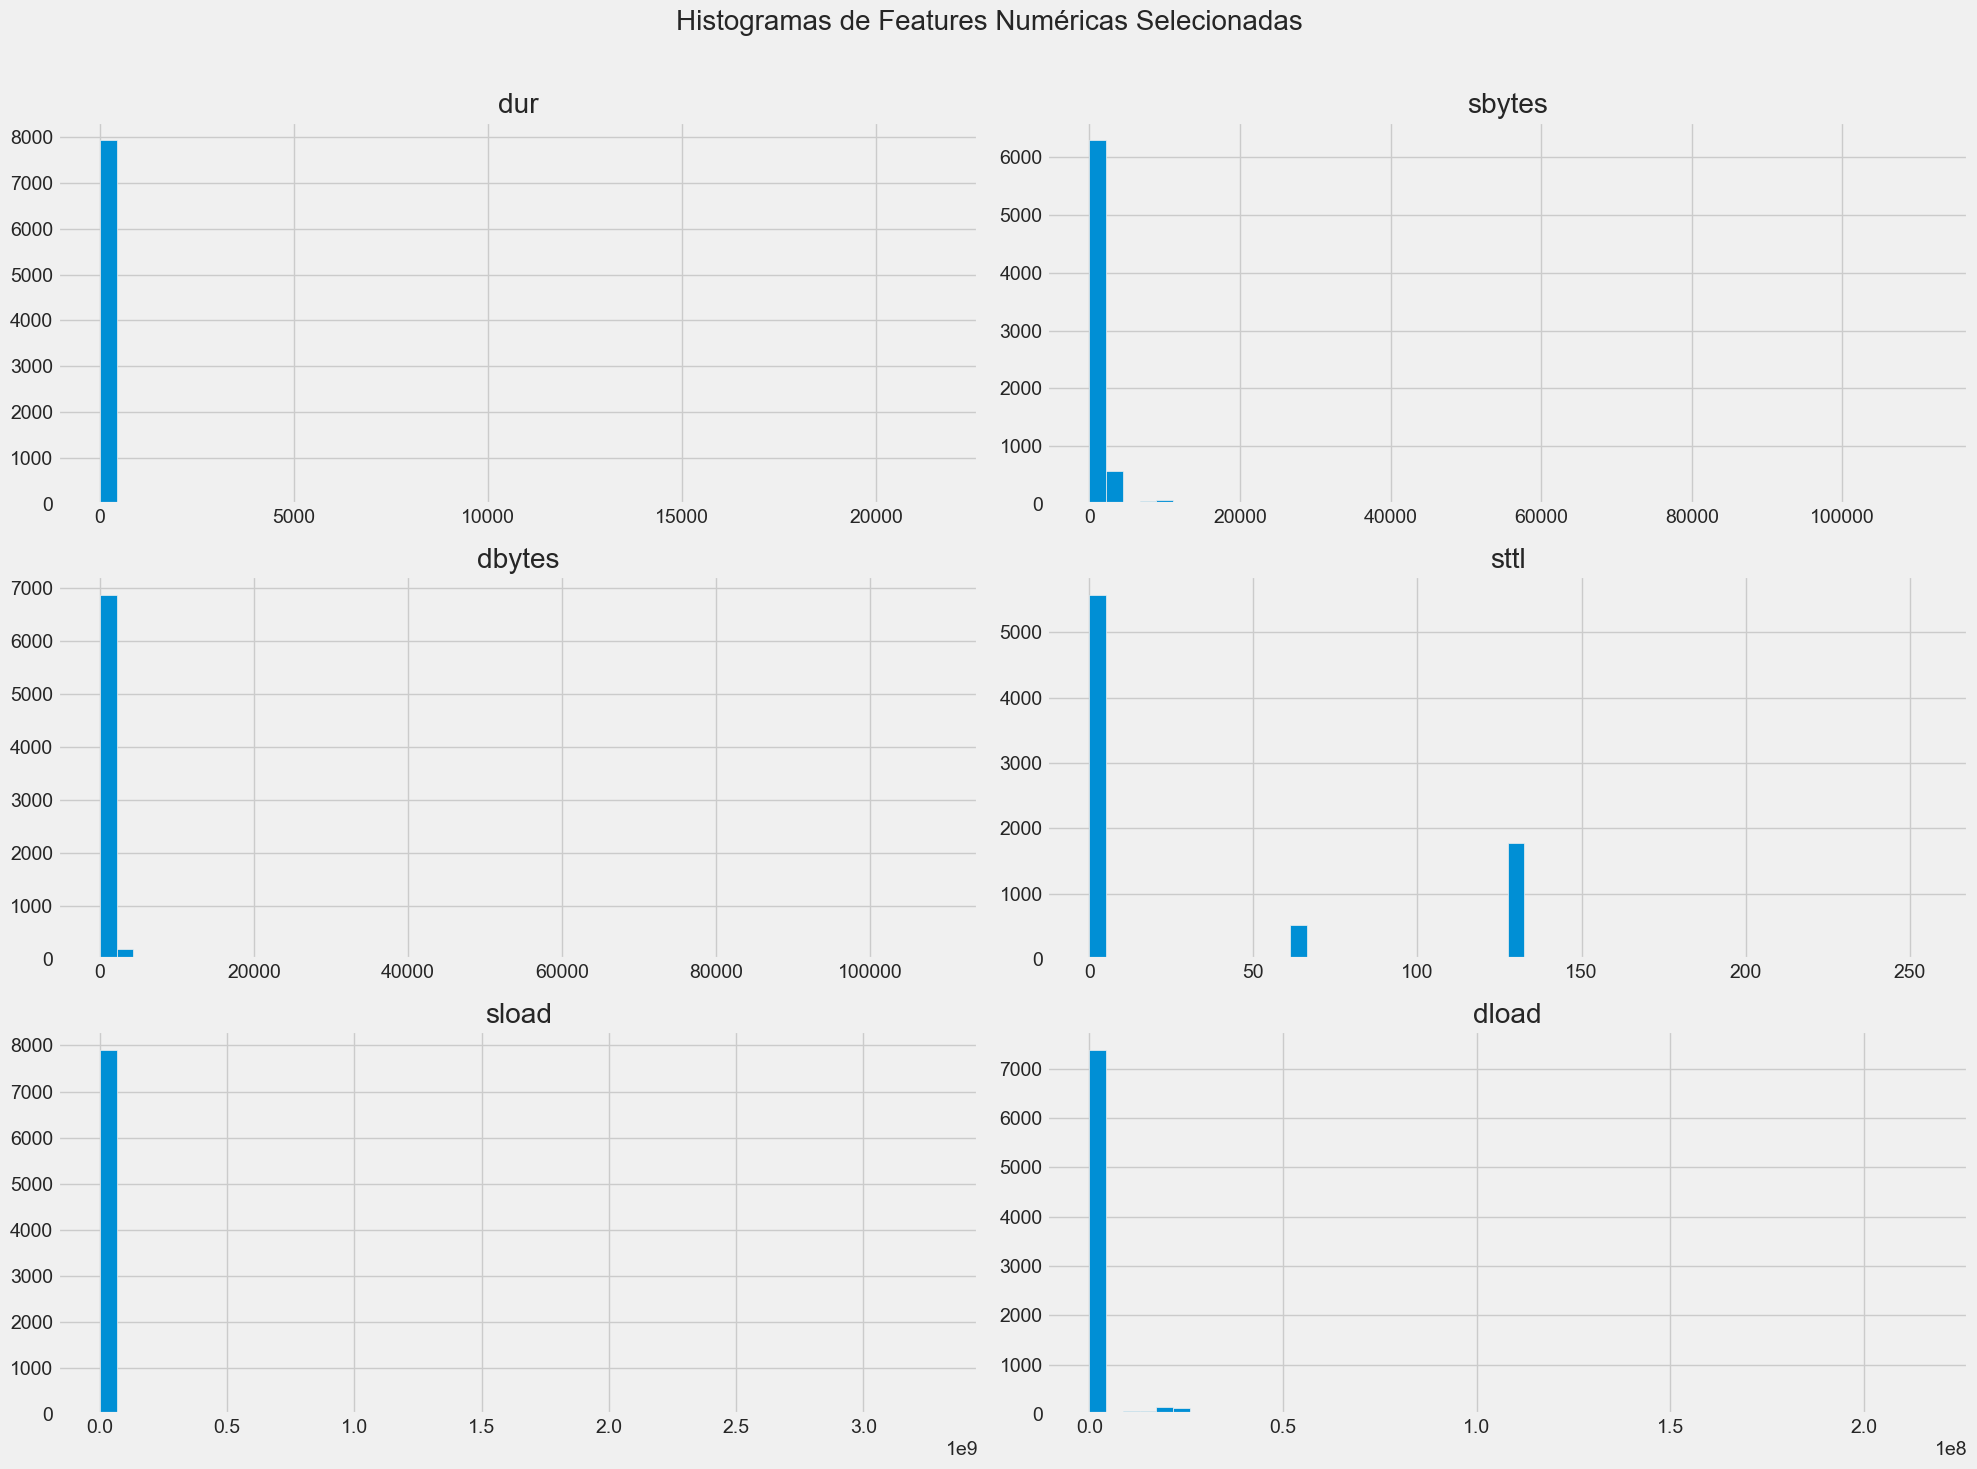

In [5]:
# Descrevendo as estatísticas das features numéricas
print("--- Estatísticas Descritivas (Features Numéricas) ---")
display(df_train.describe())

# Visualizando a distribuição de algumas features numéricas importantes
numeric_cols_to_plot = ['dur', 'sbytes', 'dbytes', 'sttl', 'sload', 'dload']
df_train[numeric_cols_to_plot].hist(bins=50, figsize=(20, 15))
plt.suptitle('Histogramas de Features Numéricas Selecionadas', size=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

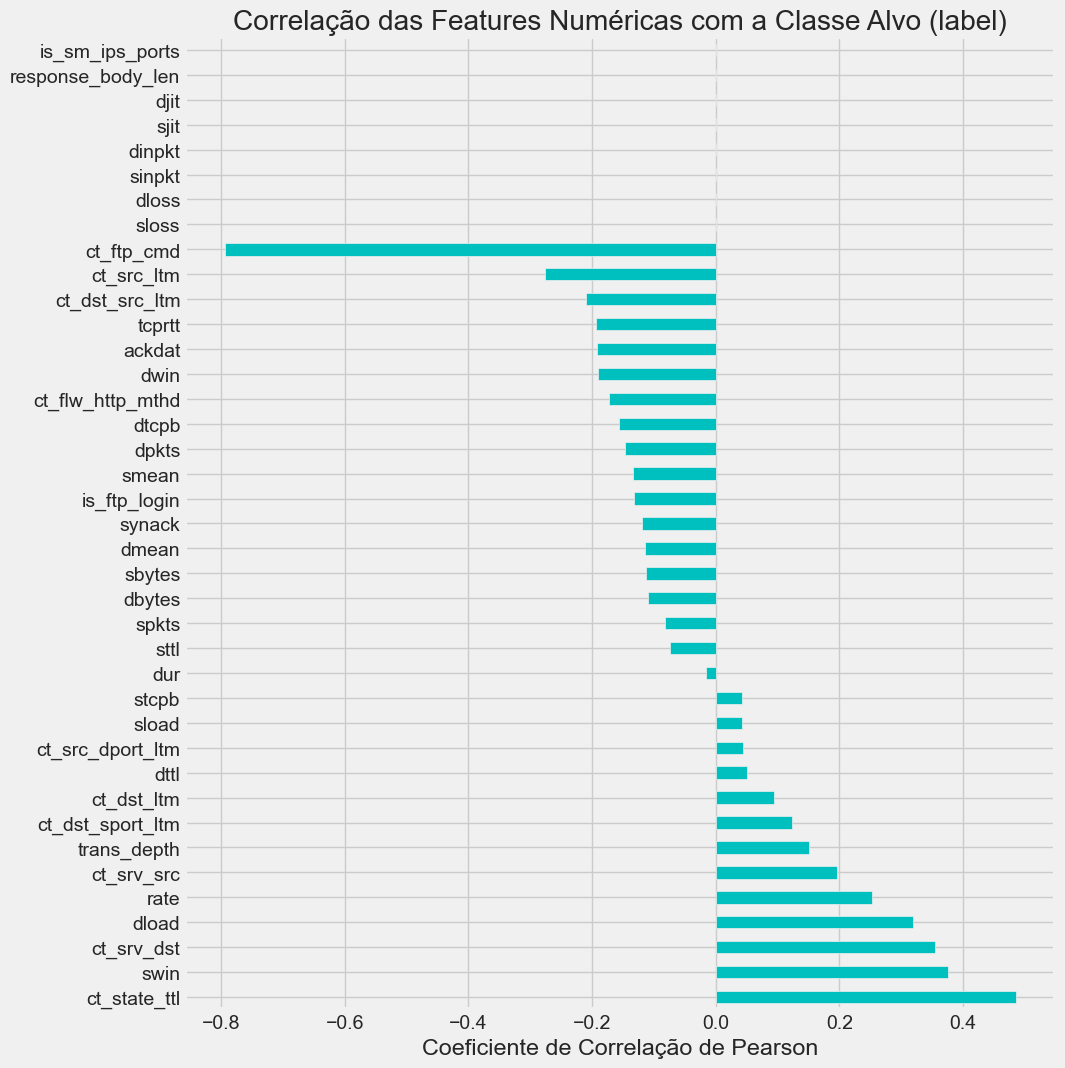

Top 10 features mais correlacionadas com 'label':
label               1.000000
ct_state_ttl        0.485118
swin                0.374914
ct_srv_dst          0.353825
dload               0.319721
rate                0.253359
ct_srv_src          0.196867
trans_depth         0.151178
ct_dst_sport_ltm    0.123281
ct_dst_ltm          0.093863
dttl                0.050624
Name: label, dtype: float64


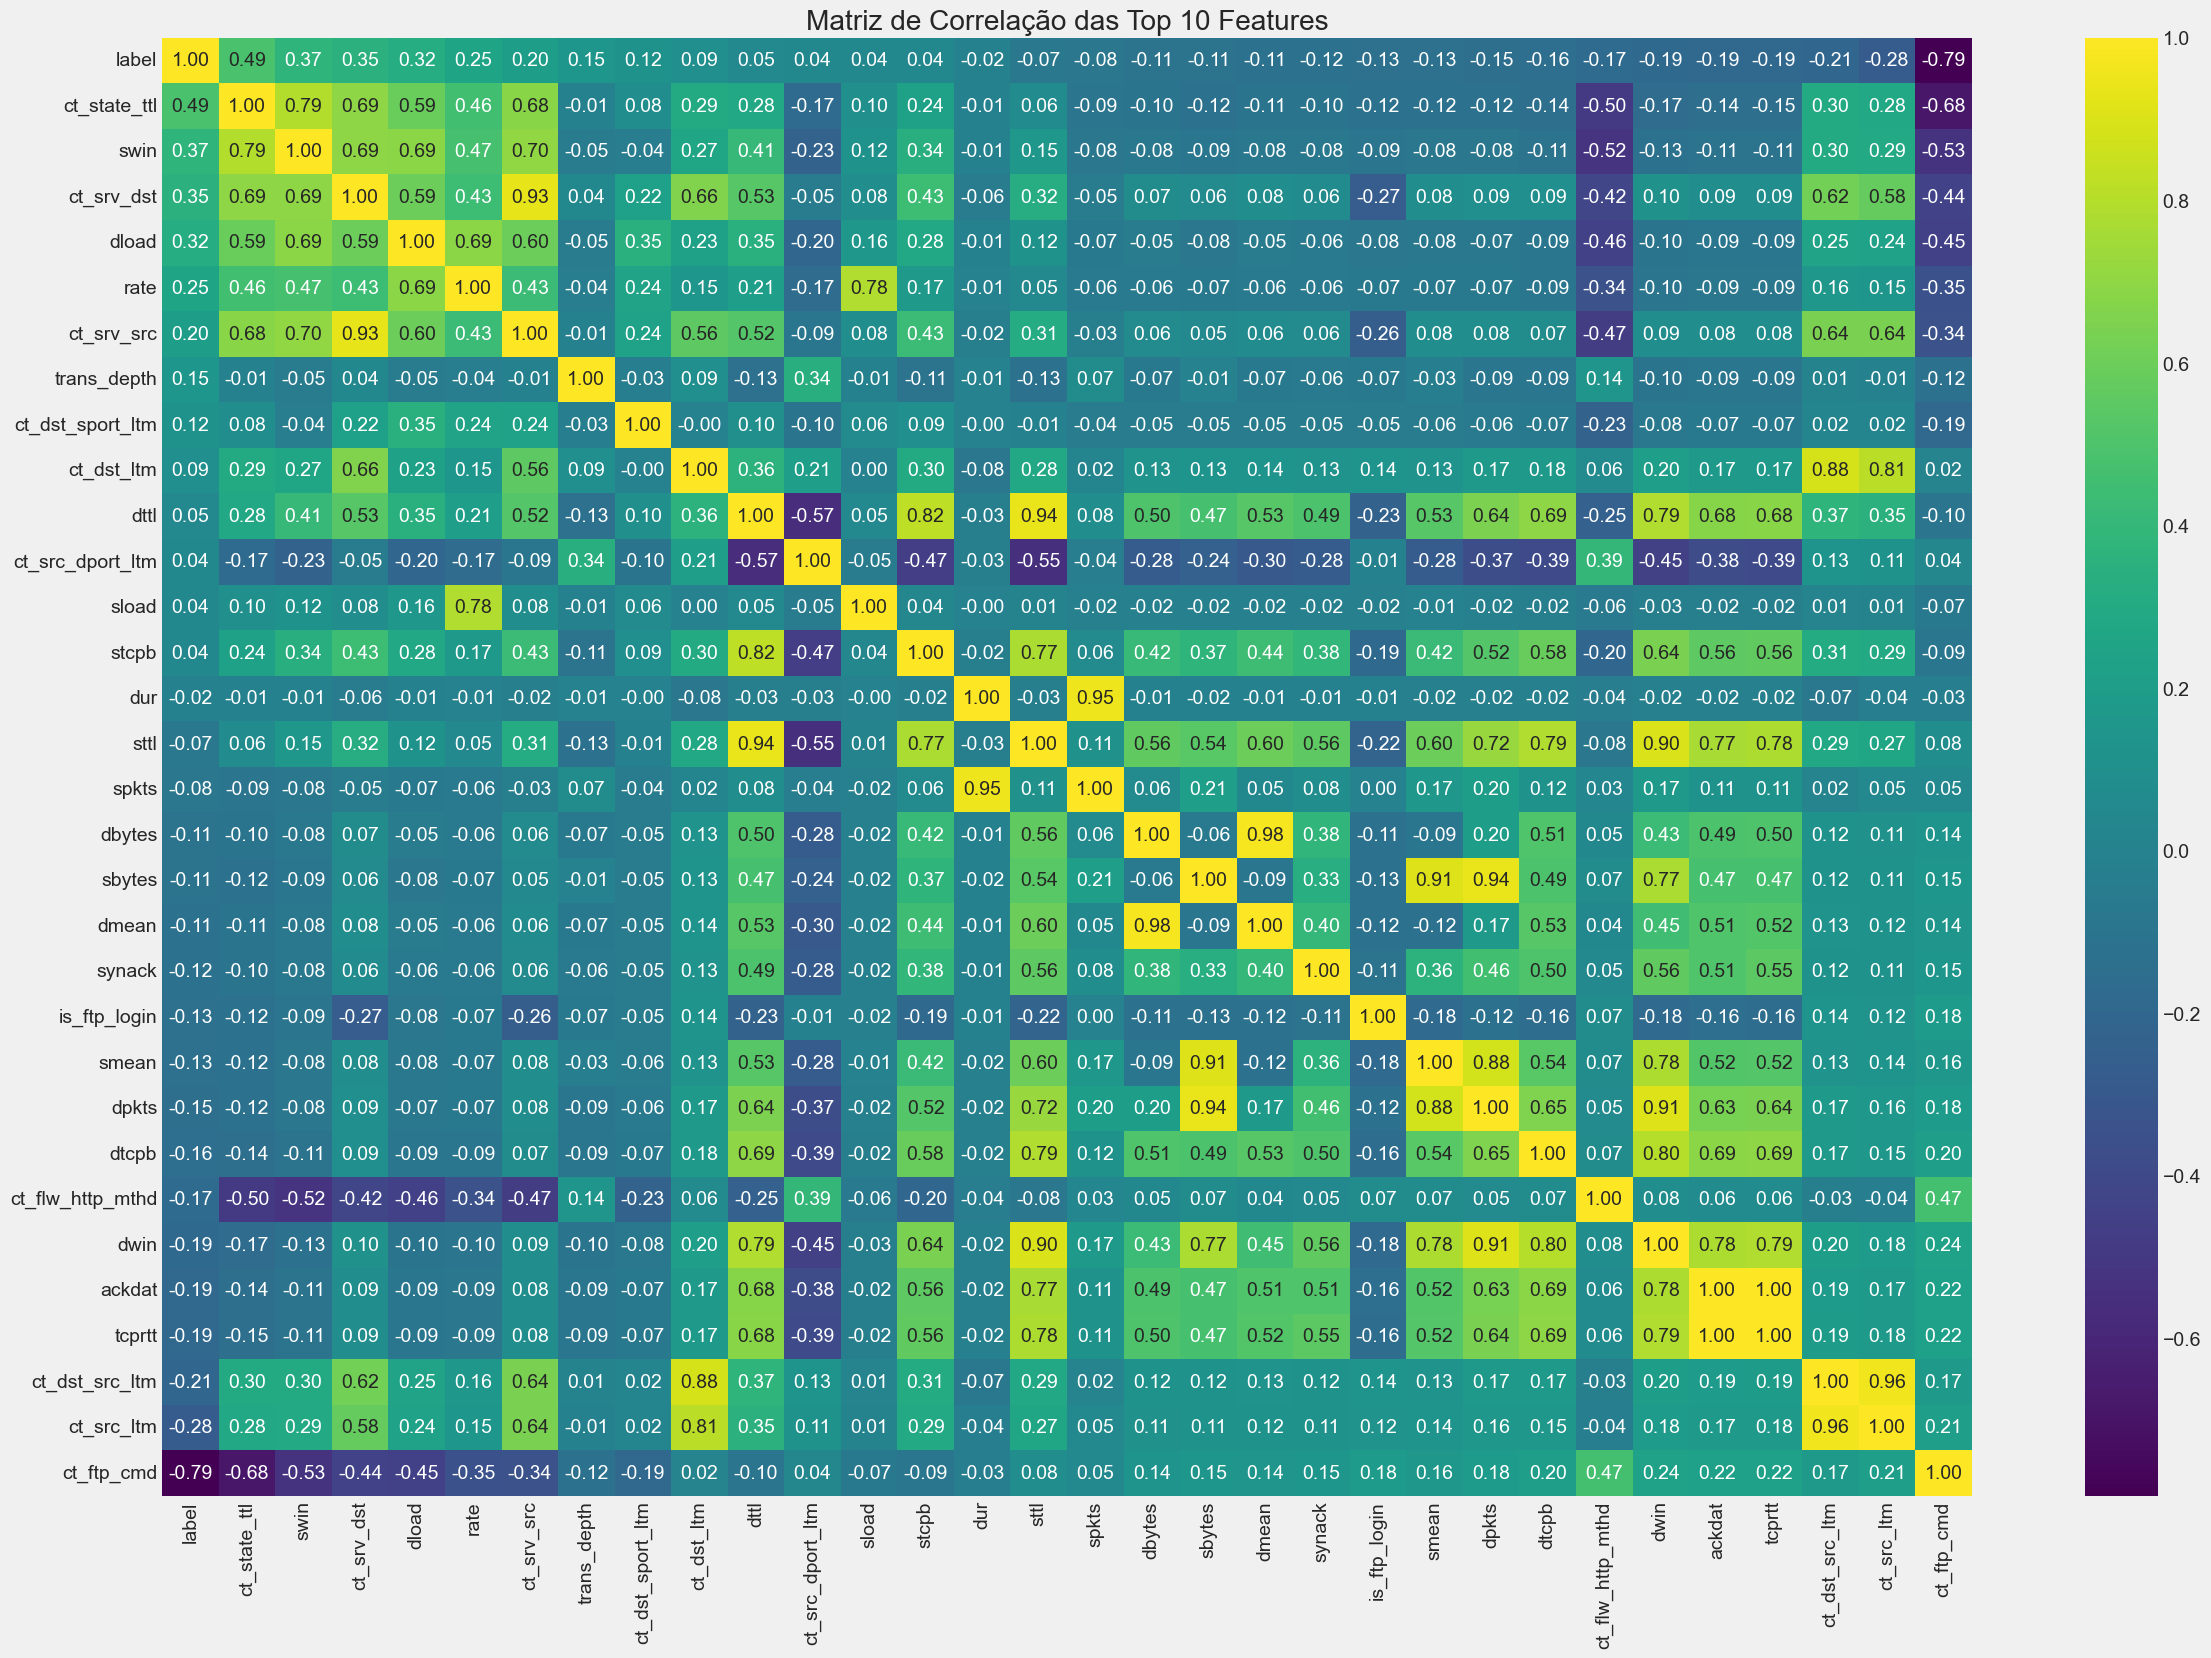

In [10]:
# Correlação das features numéricas com a variável alvo 'label'
# Excluindo 'id' e a própria 'label'
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('id')
if 'label' in numeric_cols:
    numeric_cols.remove('label')

corr_with_target = df_train[numeric_cols + ['label']].corr()['label'].sort_values(ascending=False)

plt.figure(figsize=(10, 12))
corr_with_target.drop('label').plot(kind='barh', color='c')
plt.title('Correlação das Features Numéricas com a Classe Alvo (label)')
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.show()

print("Top 10 features mais correlacionadas com 'label':")
print(corr_with_target.head(11))

# Matriz de correlação para um subconjunto das features mais correlacionadas
top_corr_features = corr_with_target.head(32).index.tolist()
plt.figure(figsize=(26, 18))
sns.heatmap(df_train[top_corr_features].corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Matriz de Correlação das Top 10 Features')
plt.show()

## Correlação por categoria de ataque (`attack_cat`)

Esta seção calcula e exibe a matriz de correlação (Pearson) entre as colunas **numéricas** para **cada ataque individual** presente em `attack_cat` (excluindo `Normal`/`Benign`, quando existirem).  
Além disso, salva os resultados (CSV + PNG) em uma pasta local para facilitar a consulta.


Colunas numéricas usadas na correlação: 39
Categorias de ataque encontradas: 3
Saída: C:\Users\GabrielMoreira\log-anomaly-detection-ml\notebooks\Ubuntu-Server-Logs-Training-Test\correlations_by_attack_cat


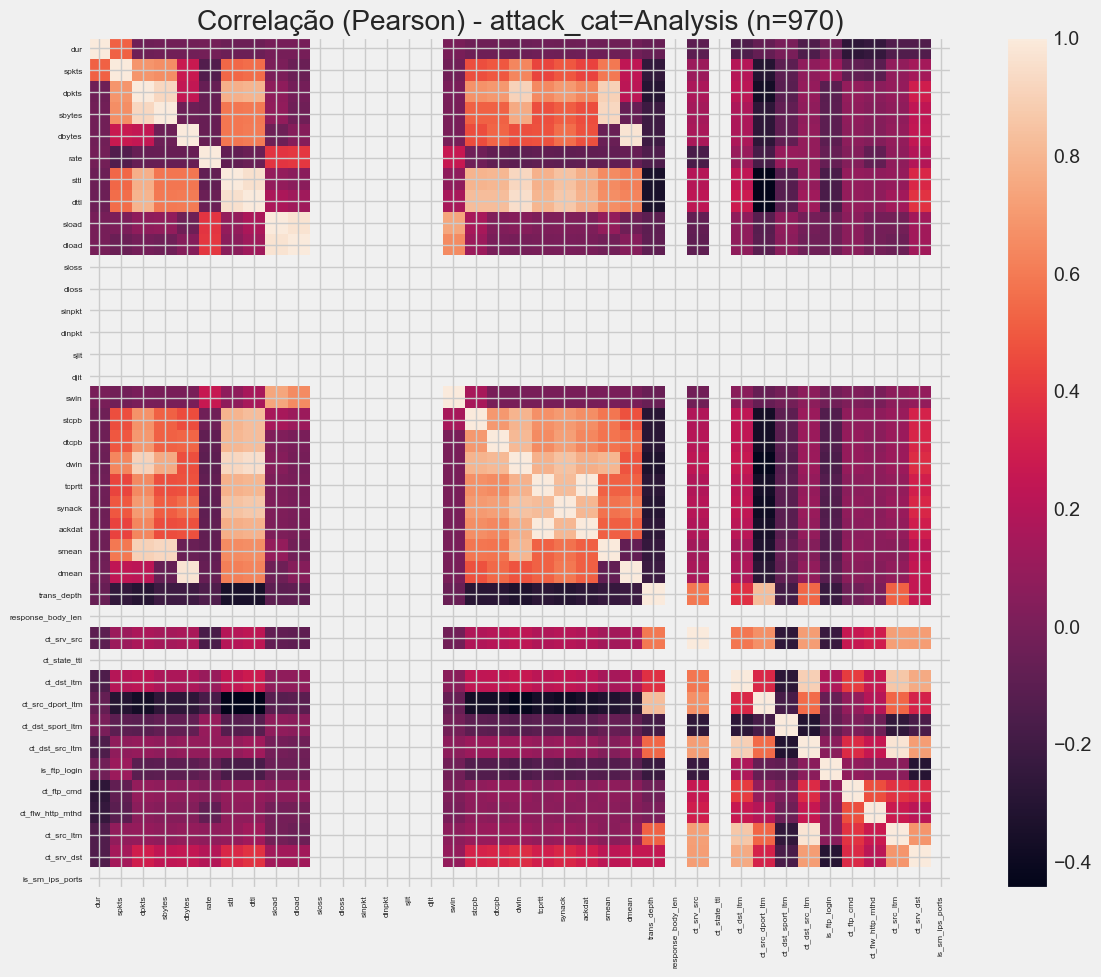

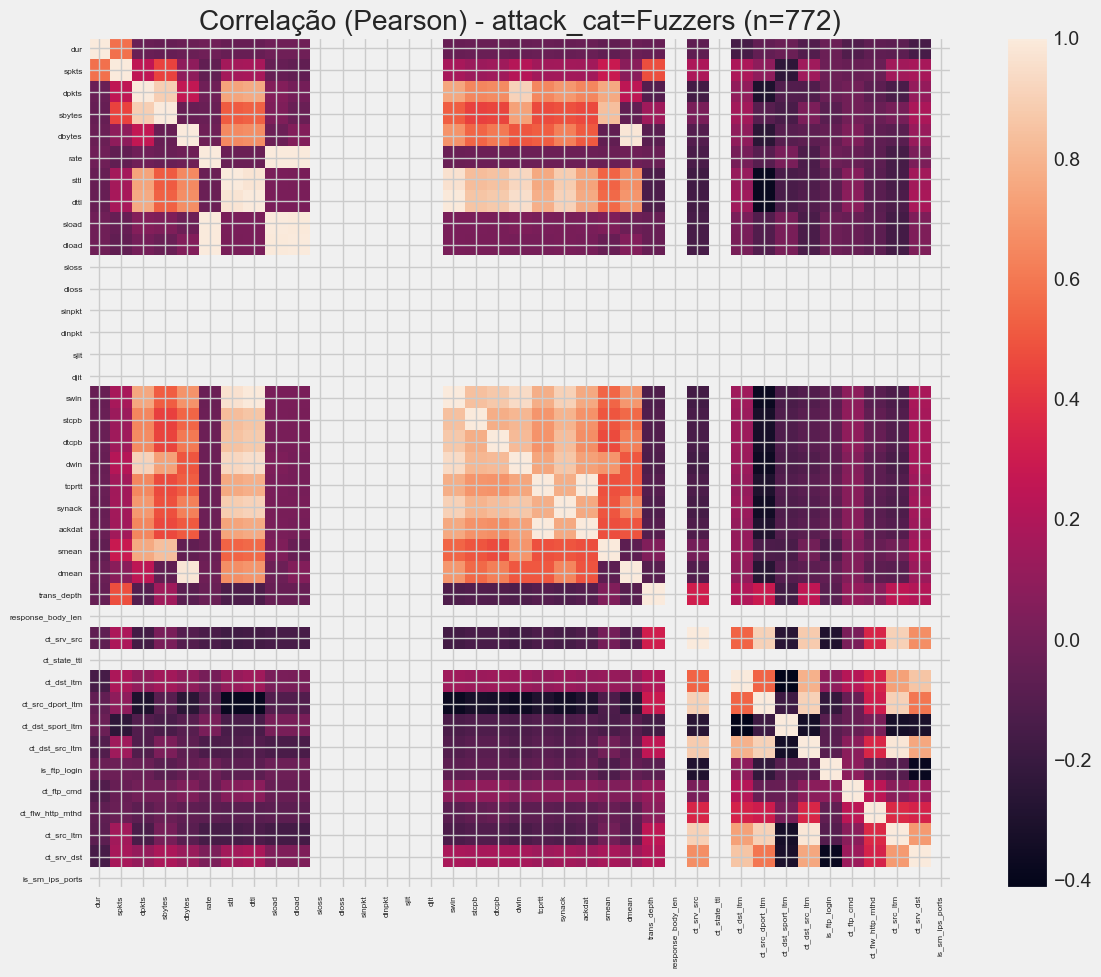

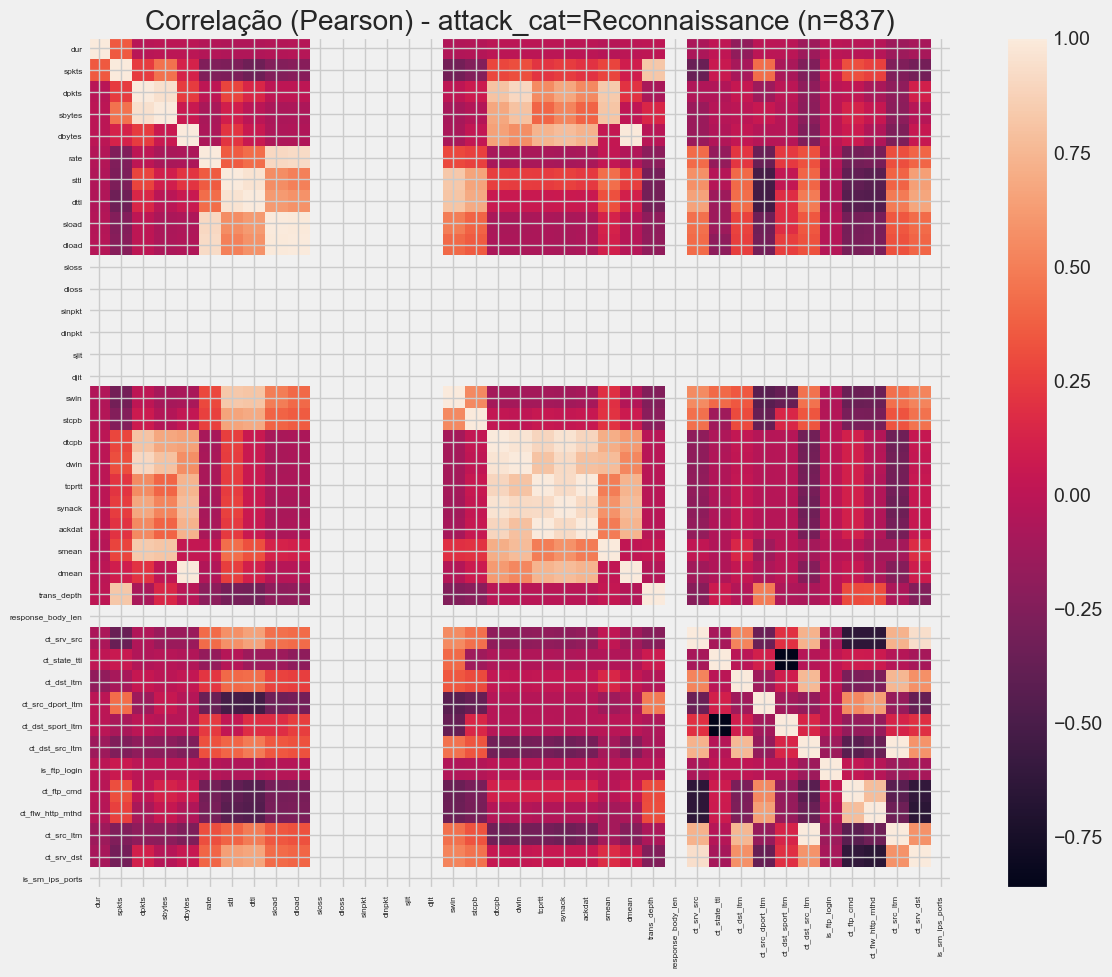

Concluído.


In [7]:
# === Correlação por categoria de ataque (attack_cat) ===
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use o dataset de treino como base (ajuste aqui se quiser usar outro dataframe)
df_base = df_train.copy()

if 'attack_cat' not in df_base.columns:
    raise KeyError("A coluna 'attack_cat' não foi encontrada em df_train. Verifique o carregamento do dataset.")

# Seleciona apenas colunas numéricas (evitando id/label)
numeric_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()
for col_to_drop in ['id', 'label']:
    if col_to_drop in numeric_cols:
        numeric_cols.remove(col_to_drop)

if len(numeric_cols) < 2:
    raise ValueError("Não há colunas numéricas suficientes para calcular correlação.")

# Lista de ataques (exclui Normal/Benign se presentes)
attack_vals = []
for v in df_base['attack_cat'].dropna().unique().tolist():
    sv = str(v).strip()
    if sv.lower() in ['normal', 'benign']:
        continue
    attack_vals.append(v)

attack_vals = sorted(attack_vals, key=lambda x: str(x))

out_dir = "./correlations_by_attack_cat"
os.makedirs(out_dir, exist_ok=True)

print(f"Colunas numéricas usadas na correlação: {len(numeric_cols)}")
print(f"Categorias de ataque encontradas: {len(attack_vals)}")
print(f"Saída: {os.path.abspath(out_dir)}")

for attack in attack_vals:
    df_a = df_base[df_base['attack_cat'] == attack]
    n = len(df_a)
    if n < 2:
        print(f"[SKIP] attack_cat={attack} (n={n}) - amostras insuficientes")
        continue

    corr = df_a[numeric_cols].corr(method='pearson')

    # Salva CSV
    safe_name = re.sub(r'[^a-zA-Z0-9_\-]+', '_', str(attack)).strip('_')
    csv_path = os.path.join(out_dir, f"corr_{safe_name}.csv")
    corr.to_csv(csv_path)

    # Plota matriz (heatmap simples com matplotlib)
    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect='auto')
    plt.title(f"Correlação (Pearson) - attack_cat={attack} (n={n})")
    plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=90, fontsize=6)
    plt.yticks(range(len(numeric_cols)), numeric_cols, fontsize=6)
    plt.colorbar()
    plt.tight_layout()

    png_path = os.path.join(out_dir, f"corr_{safe_name}.png")
    plt.savefig(png_path, dpi=200)
    plt.show()

print("Concluído.")
